# ✍️ Signature Forgery Detector — EfficientNet-B0
# Colab + Drive + LMDB Optimized
# **v4: Triplet Loss + Enhanced Augmentation + Larger Embedding + Cosine Annealing with Warmup**

## Changelog vs v3
| | v3 | v4 (this notebook) |
|---|---|---|
| Embedding dim | 256 | **512** |
| ZIP detection | Hardcoded path | **Auto-detect structure** |
| Augmentation | Basic morph + affine | **+ Perspective + stronger erasing** |
| Triplet margin | Fixed 0.5 | **Adaptive 0.3 (L2-norm space)** |
| Scheduler P1 | CosineAnnealing | **CosineAnnealingWarmRestarts** |
| Scheduler P2 | CosineAnnealing | **Linear warmup + CosineAnnealing** |
| Gradient clipping | None | **max_norm=1.0** |
| n_triplets | max 9000 | **max 12000** |
| Threshold method | macro-F1 only | **EER-optimal + macro-F1 ensemble** |
| Drive output | signature_dataset/outputs | **Fake Handwriting/outputs** |


In [1]:
!pip install torch torchvision matplotlib scikit-learn pillow numpy pandas seaborn tqdm lmdb scipy opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 6.7 MB/s eta 0:00:00


## 1. 📦 Imports & Device

In [2]:
import os, re, random, json, zipfile, shutil, time
from collections import defaultdict
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from tqdm.auto import tqdm
import lmdb
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve, f1_score
)
from scipy.optimize import brentq
from scipy.interpolate import interp1d

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥  Device : {DEVICE}')
print(f'📦 PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'🎮 GPU    : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  GPU tidak terdeteksi — pastikan Runtime -> Change runtime type -> GPU')


🖥  Device : cuda
📦 PyTorch: 2.11.0+cu128
🎮 GPU    : Tesla T4
   VRAM  : 15.6 GB


## 2. 🔗 Mount Google Drive & Lokasi ZIP

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ✅ PATH DISESUAIKAN: archive.zip ada di MyDrive/Fake Handwriting/
DRIVE_ZIP_PATH = '/content/drive/MyDrive/Fake Handwriting/archive.zip'

if not os.path.exists(DRIVE_ZIP_PATH):
    print(f'❌ Tidak ditemukan: {DRIVE_ZIP_PATH}')
    print('📤 Upload archive.zip manual sekarang...')
    from google.colab import files
    uploaded = files.upload()
    local_name = list(uploaded.keys())[0]
    os.makedirs(os.path.dirname(DRIVE_ZIP_PATH), exist_ok=True)
    shutil.copy(local_name, DRIVE_ZIP_PATH)
    print(f'✅ Disimpan ke Drive: {DRIVE_ZIP_PATH}')
else:
    print(f'✅ ZIP ditemukan di Drive: {DRIVE_ZIP_PATH}')
    print(f'   Size: {os.path.getsize(DRIVE_ZIP_PATH) / 1e6:.1f} MB')


Mounted at /content/drive
✅ ZIP ditemukan di Drive: /content/drive/MyDrive/Fake Handwriting/archive.zip
   Size: 142.7 MB


## 3. 📂 Extract ZIP ke Disk Lokal Colab

Auto-detect struktur folder dalam ZIP — tidak perlu set `ZIP_INNER` manual.

In [4]:
ZIP_PATH = DRIVE_ZIP_PATH
DATA_DIR = '/content/data/custom'
EXTS     = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

def detect_zip_inner(zip_path):
    """
    Auto-detect folder 'genuine' & 'forge' di dalam ZIP.
    Return prefix path yang harus di-strip agar struktur jadi:
      DATA_DIR/<writer_id>/genuine/... dan DATA_DIR/<writer_id>/forge/...
    """
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = zf.namelist()

    # Cari entry yang mengandung /genuine/ atau /forge/
    genuine_entries = [n for n in names if '/genuine/' in n.replace('\\', '/')]
    forge_entries   = [n for n in names if '/forge/' in n.replace('\\', '/')]

    if not genuine_entries:
        raise ValueError('❌ Tidak ditemukan folder genuine di dalam ZIP. '
                         'Pastikan struktur: .../writer_id/genuine/... dan .../writer_id/forge/...')

    # Ambil prefix sebelum writer_id (cari pola: .../something/genuine/)
    sample = genuine_entries[0].replace('\\', '/')
    parts  = sample.split('/')
    # Cari index 'genuine'
    try:
        g_idx = parts.index('genuine')
    except ValueError:
        g_idx = next(i for i, p in enumerate(parts) if p == 'genuine')
    # Writer id adalah parts[g_idx - 1], prefix adalah parts[:g_idx - 1]
    prefix_parts = parts[:g_idx - 1]
    prefix = '/'.join(prefix_parts)
    print(f'🔍 Auto-detected ZIP structure:')
    print(f'   Sample entry : {sample}')
    print(f'   Strip prefix : "{prefix}"')
    print(f'   Genuine entries: {len(genuine_entries)}')
    print(f'   Forge entries  : {len(forge_entries)}')
    return prefix, g_idx - 1  # prefix string dan depth of writer_id

ZIP_PREFIX, WRITER_DEPTH = detect_zip_inner(ZIP_PATH)

if not os.path.exists(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    print(f'\n📦 Extracting {ZIP_PATH} -> {DATA_DIR} ...')
    os.makedirs(DATA_DIR, exist_ok=True)
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        members = [m for m in zf.namelist() if not m.endswith('/')]
        # Filter hanya yang punya genuine atau forge
        members = [m for m in members
                   if '/genuine/' in m.replace('\\', '/') or
                      '/forge/'   in m.replace('\\', '/')]
        for member in tqdm(members, desc='Extracting'):
            norm = member.replace('\\', '/')
            parts = norm.split('/')
            if len(parts) <= WRITER_DEPTH:
                continue
            rel_parts = parts[WRITER_DEPTH:]   # [writer_id, genuine/forge, filename]
            if len(rel_parts) < 3:
                continue
            dest = os.path.join(DATA_DIR, *rel_parts)
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            with zf.open(member) as src, open(dest, 'wb') as dst:
                dst.write(src.read())
    print(f'✅ Extracted in {time.time() - t0:.1f}s -> {DATA_DIR}')
else:
    print(f'✅ Dataset sudah ada di {DATA_DIR} (skip extract)')

gen_count  = sum(1 for root, _, files in os.walk(DATA_DIR)
                 for f in files if 'genuine' in root and f.lower().endswith(EXTS))
forg_count = sum(1 for root, _, files in os.walk(DATA_DIR)
                 for f in files if 'forge' in root and f.lower().endswith(EXTS))
print(f'\n📊 Dataset Summary')
print(f'   Genuine : {gen_count}')
print(f'   Forged  : {forg_count}')
print(f'   Total   : {gen_count + forg_count}')


🔍 Auto-detected ZIP structure:
   Sample entry : New folder (10)/test/1/genuine/c-001-17 (Copy).jpg
   Strip prefix : "New folder (10)/test"
   Genuine entries: 3600
   Forge entries  : 4500

📦 Extracting /content/drive/MyDrive/Fake Handwriting/archive.zip -> /content/data/custom ...


Extracting:   0%|          | 0/8100 [00:00<?, ?it/s]

✅ Extracted in 2.3s -> /content/data/custom

📊 Dataset Summary
   Genuine : 1200
   Forged  : 2100
   Total   : 3300


## 4. 🗂 Writer-Aware File Index

Writers with genuine & forged: 150
  Writer    1: 8 genuine, 14 forged
  Writer   10: 8 genuine, 14 forged
  Writer  100: 8 genuine, 14 forged
  Writer  101: 8 genuine, 14 forged
  Writer  102: 8 genuine, 14 forged


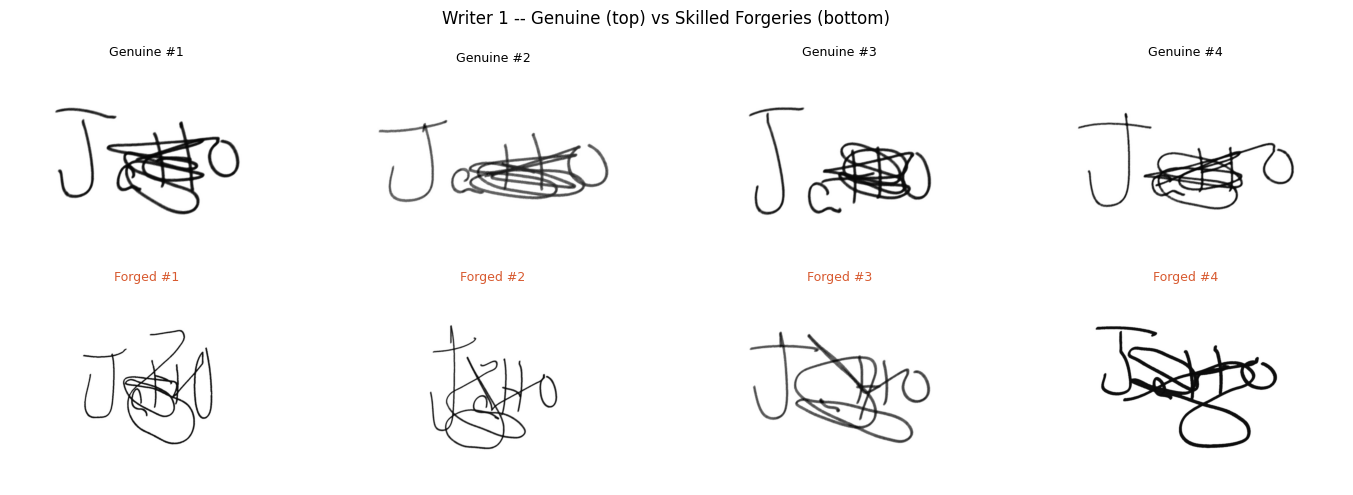

In [5]:
def build_index(data_dir, label_folder):
    index = defaultdict(list)
    for writer_id in sorted(os.listdir(data_dir)):
        folder = os.path.join(data_dir, writer_id, label_folder)
        if not os.path.isdir(folder):
            continue
        for fname in sorted(os.listdir(folder)):
            if fname.lower().endswith(EXTS):
                index[writer_id].append(os.path.join(folder, fname))
    return dict(index)

genuine_index = build_index(DATA_DIR, 'genuine')
forged_index  = build_index(DATA_DIR, 'forge')

writers = sorted(set(genuine_index) & set(forged_index))
print(f'Writers with genuine & forged: {len(writers)}')
for wid in writers[:5]:
    print(f'  Writer {wid:>4}: {len(genuine_index[wid])} genuine, {len(forged_index[wid])} forged')

wid_ex = writers[0]
n_show = min(4, len(genuine_index[wid_ex]), len(forged_index[wid_ex]))
fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 5))
fig.suptitle(f'Writer {wid_ex} -- Genuine (top) vs Skilled Forgeries (bottom)', fontsize=12)
for i in range(n_show):
    axes[0, i].imshow(Image.open(genuine_index[wid_ex][i]), cmap='gray')
    axes[0, i].set_title(f'Genuine #{i+1}', fontsize=9); axes[0, i].axis('off')
    axes[1, i].imshow(Image.open(forged_index[wid_ex][i]), cmap='gray')
    axes[1, i].set_title(f'Forged #{i+1}', fontsize=9, color='#D85A30'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()


## 5. Build LMDB Cache (Autocrop + Pre-resize 224×224)

In [6]:
IMG_SIZE_CACHE = 224
LMDB_PATH      = '/content/cache/signature_cache_autocrop_v4.lmdb'
os.makedirs(os.path.dirname(LMDB_PATH), exist_ok=True)

all_paths = sorted(set(
    p for paths in genuine_index.values() for p in paths
) | set(
    p for paths in forged_index.values()  for p in paths
))
print(f'Total gambar unik untuk di-cache: {len(all_paths)}')


def autocrop_and_pad(img, pad_frac=0.08, ink_thresh=245, size=IMG_SIZE_CACHE):
    """Crop ke bounding box tinta, pad ke square, resize."""
    gray = np.array(img.convert('L'))
    mask = gray < ink_thresh
    if mask.sum() == 0:
        cropped = img.convert('RGB')
    else:
        ys, xs = np.where(mask)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())
        h, w   = gray.shape
        pad_y  = max(2, int((y1 - y0 + 1) * pad_frac))
        pad_x  = max(2, int((x1 - x0 + 1) * pad_frac))
        y0, y1 = max(0, y0 - pad_y), min(h - 1, y1 + pad_y)
        x0, x1 = max(0, x0 - pad_x), min(w - 1, x1 + pad_x)
        cropped = img.convert('RGB').crop((x0, y0, x1 + 1, y1 + 1))
    cw, ch = cropped.size
    side   = max(cw, ch)
    canvas = Image.new('RGB', (side, side), (255, 255, 255))
    canvas.paste(cropped, ((side - cw) // 2, (side - ch) // 2))
    return canvas.resize((size, size), Image.BILINEAR)


def _resize_one(path, size=IMG_SIZE_CACHE):
    try:
        img = Image.open(path)
        img = autocrop_and_pad(img, size=size)
        return path, np.asarray(img, dtype=np.uint8).tobytes()
    except Exception:
        return path, None

def build_lmdb_cache(paths, lmdb_path, size=IMG_SIZE_CACHE, map_size_gb=4, n_workers=None):
    n_workers = n_workers or min(8, os.cpu_count() or 4)
    env = lmdb.open(lmdb_path, map_size=int(map_size_gb * 1e9))
    with env.begin(write=False) as txn:
        existing = txn.get(b'__count__')
    if existing is not None and int(existing) == len(paths):
        print(f'✅ LMDB cache sudah lengkap ({len(paths)} entri) -- skip rebuild.')
        env.close(); return
    written = 0
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(_resize_one, p): p for p in paths}
        with env.begin(write=True) as txn:
            for fut in tqdm(as_completed(futures), total=len(futures), desc='Building LMDB cache'):
                path, data = fut.result()
                if data is not None:
                    txn.put(path.encode('utf-8'), data)
                    written += 1
    with env.begin(write=True) as txn:
        txn.put(b'__count__', str(len(paths)).encode('utf-8'))
        txn.put(b'__size__',  str(size).encode('utf-8'))
    env.close()
    print(f'✅ LMDB cache built: {written}/{len(paths)} gambar in {time.time()-t0:.1f}s -> {lmdb_path}')

build_lmdb_cache(all_paths, LMDB_PATH, size=IMG_SIZE_CACHE)

def _lmdb_dir_size(path):
    if os.path.isfile(path): return os.path.getsize(path)
    return sum(os.path.getsize(os.path.join(path, f)) for f in os.listdir(path))
print(f'\n📦 Ukuran LMDB cache: {_lmdb_dir_size(LMDB_PATH) / 1e6:.1f} MB')


Total gambar unik untuk di-cache: 3300


Building LMDB cache:   0%|          | 0/3300 [00:00<?, ?it/s]

✅ LMDB cache built: 3300/3300 gambar in 58.1s -> /content/cache/signature_cache_autocrop_v4.lmdb

📦 Ukuran LMDB cache: 500.4 MB


## 6. 🎨 Augmentasi Khusus Tanda Tangan (v4 — Diperkuat)

Augmentasi berikut dirancang khusus untuk variasi realistis pada tanda tangan:
- **Stroke thickness variation** — dilation/erosion untuk simulasi pen pressure berbeda
- **Gaussian blur** — simulasi pen speed tinggi atau kualitas scan rendah
- **RandomAffine** — rotasi kecil & translasi (tanpa flip horizontal)
- **RandomPerspective** — distorsi perspektif ringan, simulasi sudut scan berbeda *(baru v4)*
- **ColorJitter** — variasi brightness/contrast antar scan
- **RandomErasing** — lebih agresif dari v3 untuk robustness *(ditingkatkan v4)*


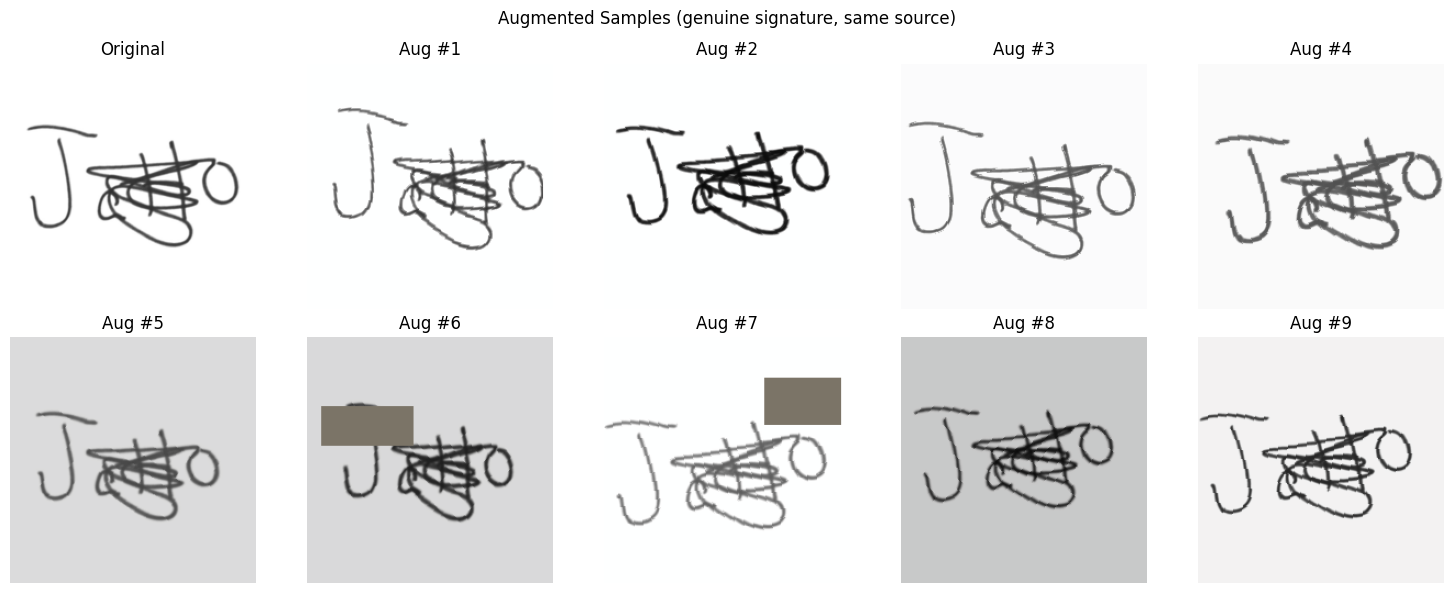

✅ Augmentation pipeline siap


In [ ]:
class SignatureAugmentation:
    """
    Augmentasi morfologi khusus tanda tangan.
    Dipanggil SEBELUM transforms.ToTensor() (bekerja pada PIL Image).
    """

    def __init__(self, dilate_p=0.25, erode_p=0.25, blur_p=0.30,
                 kernel_size=(2, 2), blur_radius_range=(0.3, 0.9)):
        self.dilate_p          = dilate_p
        self.erode_p           = erode_p
        self.blur_p            = blur_p
        self.kernel            = np.ones(kernel_size, np.uint8)
        self.blur_radius_range = blur_radius_range

    def _stroke_variation(self, img):
        arr = np.array(img.convert('L'))
        inv = 255 - arr
        r   = random.random()
        if r < self.dilate_p:
            inv = cv2.dilate(inv, self.kernel, iterations=1)
        elif r < self.dilate_p + self.erode_p:
            inv = cv2.erode(inv, self.kernel, iterations=1)
        result = Image.fromarray(255 - inv)
        return result.convert('RGB')

    def _blur(self, img):
        if random.random() < self.blur_p:
            radius = random.uniform(*self.blur_radius_range)
            return img.filter(ImageFilter.GaussianBlur(radius=radius))
        return img

    def __call__(self, img):
        img = self._stroke_variation(img)
        img = self._blur(img)
        return img


IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

_sig_aug = SignatureAugmentation()

train_transform = transforms.Compose([
    # 1. Signature-specific morphological augmentation (PIL → PIL)
    transforms.Lambda(lambda img: _sig_aug(img)),
    # 2. Geometric: small rotation + translation, NO horizontal flip
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.90, 1.10),
                            fill=255),
    # 3. [NEW v4] Perspective distortion — simulasi sudut scan berbeda
    transforms.RandomPerspective(distortion_scale=0.15, p=0.40, fill=255),
    # 4. Photometric
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.10),
    # 5. To tensor + normalize
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    # 6. Random erasing — ditingkatkan dari v3 (p=0.15 → 0.25, scale lebih besar)
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.0)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Quick sanity-check: visualize augmented samples
wid_ex   = writers[0]
orig_img = Image.open(genuine_index[wid_ex][0])
orig_img = autocrop_and_pad(orig_img, size=IMG_SIZE)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmented Samples (genuine signature, same source)', fontsize=12)
axes[0, 0].imshow(orig_img); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')
for i in range(1, 10):
    aug = train_transform(orig_img.copy())
    img_np = aug.permute(1, 2, 0).numpy()
    img_np = img_np * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_np = np.clip(img_np, 0, 1)
    r, c = divmod(i, 5)
    axes[r, c].imshow(img_np); axes[r, c].set_title(f'Aug #{i}'); axes[r, c].axis('off')
plt.tight_layout(); plt.show()
print('✅ Augmentation pipeline siap')


## 7. 🔗 Triplet Dataset (LMDB-backed)

Dataset menghasilkan triplet `(anchor, positive, negative)`:
- **Anchor** = genuine dari writer W
- **Positive** = genuine lain dari writer W (same-writer)
- **Negative** = forged dari writer W (50%) ATAU genuine dari writer lain (50%)


In [8]:
class TripletSignatureDataset(Dataset):
    """
    Menghasilkan triplet (anchor_genuine, positive_genuine, negative).
    resample(epoch) dipanggil di awal setiap epoch agar triplet selalu fresh.
    """

    def __init__(self, genuine_index, forged_index, writers, lmdb_path,
                 img_size=224, transform=None, n_triplets=3000,
                 forged_ratio=0.50, seed=SEED):
        self.genuine_index = genuine_index
        self.forged_index  = forged_index
        self.writers       = writers
        self.lmdb_path     = lmdb_path
        self.img_size      = img_size
        self.transform     = transform
        self.n_triplets    = n_triplets
        self.forged_ratio  = forged_ratio
        self.base_seed     = seed
        self.env           = None
        self.triplets      = self._draw_triplets(seed)

    def _draw_triplets(self, seed):
        rng       = np.random.RandomState(seed)
        triplets  = []
        n_forged   = int(self.n_triplets * self.forged_ratio)
        n_impostor = self.n_triplets - n_forged

        for _ in range(n_forged):
            wid = rng.choice(self.writers)
            g   = self.genuine_index[wid]
            f   = self.forged_index[wid]
            a, p = (rng.choice(g, 2, replace=False) if len(g) >= 2 else (g[0], g[0]))
            n = rng.choice(f)
            triplets.append((a, p, n))

        for _ in range(n_impostor):
            wa, wb = rng.choice(self.writers, 2, replace=False)
            ga = self.genuine_index[wa]
            gb = self.genuine_index[wb]
            a, p = (rng.choice(ga, 2, replace=False) if len(ga) >= 2 else (ga[0], ga[0]))
            n = rng.choice(gb)
            triplets.append((a, p, n))

        rng.shuffle(triplets)
        return triplets

    def resample(self, epoch):
        self.triplets = self._draw_triplets(self.base_seed + epoch * 1000)

    def _ensure_env(self):
        if self.env is None:
            self.env = lmdb.open(self.lmdb_path, readonly=True, lock=False,
                                 readahead=False, max_readers=256)

    def _load(self, path):
        self._ensure_env()
        with self.env.begin(write=False) as txn:
            buf = txn.get(path.encode('utf-8'))
        if buf is None:
            img = Image.open(path).convert('RGB').resize(
                (self.img_size, self.img_size), Image.BILINEAR)
            return img
        arr = np.frombuffer(buf, dtype=np.uint8).reshape(self.img_size, self.img_size, 3)
        return Image.fromarray(arr)

    def __len__(self): return len(self.triplets)

    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]
        anchor   = self._load(a_path)
        positive = self._load(p_path)
        negative = self._load(n_path)
        if self.transform:
            anchor   = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)
        return anchor, positive, negative


# Train/val writer split
rng_split = np.random.RandomState(SEED)
shuffled  = list(writers); rng_split.shuffle(shuffled)
cut       = int(len(shuffled) * 0.8)
train_writers, val_writers = shuffled[:cut], shuffled[cut:]
print(f'Train writers: {len(train_writers)} | Val writers: {len(val_writers)}')

total_imgs    = sum(len(v) for v in genuine_index.values())
# ✅ v4: n_triplets ditingkatkan (max 12000 dari sebelumnya 9000)
n_train_trips = max(4000, min(12000, total_imgs * 6))
n_val_trips   = max(1000, min(3000, total_imgs))

train_dataset = TripletSignatureDataset(
    genuine_index, forged_index, train_writers, LMDB_PATH,
    img_size=IMG_SIZE_CACHE, transform=train_transform,
    n_triplets=n_train_trips, forged_ratio=0.50)

val_dataset = TripletSignatureDataset(
    genuine_index, forged_index, val_writers, LMDB_PATH,
    img_size=IMG_SIZE_CACHE, transform=val_transform,
    n_triplets=n_val_trips, forged_ratio=0.50)

NUM_WORKERS  = min(8, os.cpu_count() or 4)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=False, prefetch_factor=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

print(f'\n✅ Train: {len(train_dataset)} triplets | Val: {len(val_dataset)} triplets')
print(f'   Negative composition: 50% skilled-forgery / 50% impostor')
print(f'   num_workers={NUM_WORKERS}')


Train writers: 120 | Val writers: 30

✅ Train: 7200 triplets | Val: 1200 triplets
   Negative composition: 50% skilled-forgery / 50% impostor
   num_workers=2


## 8. 🧠 EfficientNet-B0 Embedder + Triplet Loss

**v4 changes:**
- Embedding dim ditingkatkan dari **256 → 512** untuk representasi lebih kaya
- Margin triplet dikurangi dari **0.5 → 0.3** — lebih cocok untuk embedding L2-norm (range [0,2]) karena margin yang lebih ketat mendorong cluster yang lebih compact
- Tambahan **BatchNorm** di akhir head untuk stabilisasi training


In [9]:
class EfficientNetEmbedder(nn.Module):
    """
    EfficientNet-B0 backbone dengan projection head.
    Output adalah L2-normalized embeddings (unit sphere).

    v4: embedding_dim=512, tambah BN di akhir head.
    """

    def __init__(self, embedding_dim=512, dropout=0.4):
        super().__init__()
        efficientnet  = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(efficientnet.features, efficientnet.avgpool)
        backbone_out  = 1280
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(backbone_out, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim),   # ← baru v4: stabilisasi embedding space
        )
        self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False
        print('🔒 Backbone frozen (training projection head only)')

    def unfreeze_last_n_blocks(self, n=5):
        """
        Unfreeze n block terakhir dari EfficientNet features.
        EfficientNet-B0 features = [stem, MBConv_block_0..8, head_conv]
        """
        blocks = list(self.backbone[0].children())
        unfreeze_from = max(0, len(blocks) - n)
        for i, block in enumerate(blocks):
            for p in block.parameters():
                p.requires_grad = (i >= unfreeze_from)
        total_unf = sum(p.numel() for b in blocks[unfreeze_from:]
                        for p in b.parameters() if p.requires_grad)
        print(f'🔓 Unfroze last {n} backbone blocks ({total_unf:,} parameters)')

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return F.normalize(x, p=2, dim=1)   # unit-sphere embedding


class TripletLoss(nn.Module):
    """
    Triplet Loss dengan margin.
    v4: margin=0.3 (lebih tight dari 0.5) untuk embedding L2-normalized.
    Margin lebih kecil mendorong cluster yang lebih compact di embedding space.
    """
    def __init__(self, margin=0.3):
        super().__init__()
        self.loss_fn = nn.TripletMarginLoss(margin=margin, p=2, reduction='mean')

    def forward(self, anchor, positive, negative):
        return self.loss_fn(anchor, positive, negative)


# ✅ v4: embedding_dim=512
model     = EfficientNetEmbedder(embedding_dim=512, dropout=0.4).to(DEVICE)
criterion = TripletLoss(margin=0.3)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✅ Model ready')
print(f'   Total parameters    : {total_p:,}')
print(f'   Trainable (Phase 1) : {trainable_p:,}')
print(f'   Embedding dim       : 512')
print(f'   Loss                : TripletMarginLoss (margin=0.3)')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


🔒 Backbone frozen (training projection head only)

✅ Model ready
   Total parameters    : 4,928,124
   Trainable (Phase 1) : 920,576
   Embedding dim       : 512
   Loss                : TripletMarginLoss (margin=0.3)


## 9. 🏋 Two-Phase Training — AMP + Gradient Clipping

**Phase 1** (15 epoch): Backbone frozen, hanya projection head yang dilatih.
Scheduler: `CosineAnnealingWarmRestarts` (T_0=5) agar learning rate restart beberapa kali, menghindari local minima.

**Phase 2** (20 epoch): Unfreeze 5 block terakhir dengan differential LR.
Scheduler: Linear warmup (3 epoch) → CosineAnnealing, mencegah gradient spike saat fine-tune dimulai.

**v4 additions:**
- `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` — gradient clipping untuk stabilitas
- Phase 2 lebih panjang (15 → 20 epoch) karena fine-tune butuh lebih banyak iterasi


In [10]:
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

GRAD_CLIP_NORM = 1.0  # ← v4: gradient clipping

def triplet_accuracy(anchor_emb, pos_emb, neg_emb):
    """Akurasi triplet: benar jika dist(a,p) < dist(a,n)."""
    d_pos = F.pairwise_distance(anchor_emb, pos_emb)
    d_neg = F.pairwise_distance(anchor_emb, neg_emb)
    return (d_pos < d_neg).float().mean().item()


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for anchor, positive, negative in loader:
        anchor   = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)
        negative = negative.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)
            loss  = criterion(emb_a, emb_p, emb_n)
        scaler.scale(loss).backward()
        # ✅ v4: gradient clipping — unscale dulu baru clip
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        total_acc  += triplet_accuracy(emb_a.detach(), emb_p.detach(), emb_n.detach())
        n_batches  += 1
    return total_loss / n_batches, total_acc / n_batches


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    all_d_pos, all_d_neg = [], []
    with torch.no_grad():
        for anchor, positive, negative in loader:
            anchor   = anchor.to(device, non_blocking=True)
            positive = positive.to(device, non_blocking=True)
            negative = negative.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                emb_a = model(anchor)
                emb_p = model(positive)
                emb_n = model(negative)
                loss  = criterion(emb_a, emb_p, emb_n)
            d_pos = F.pairwise_distance(emb_a, emb_p).float().cpu().numpy()
            d_neg = F.pairwise_distance(emb_a, emb_n).float().cpu().numpy()
            total_loss += loss.item()
            total_acc  += triplet_accuracy(emb_a, emb_p, emb_n)
            n_batches  += 1
            all_d_pos.extend(d_pos.tolist())
            all_d_neg.extend(d_neg.tolist())
    return total_loss / n_batches, total_acc / n_batches, all_d_pos, all_d_neg


# ── Phase 1: Head warm-up ────────────────────────────────────────────────
PHASE1_EPOCHS = 15
PHASE2_EPOCHS = 20   # ✅ v4: ditingkatkan dari 15
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best_val_acc = 0.0

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
# ✅ v4: CosineAnnealingWarmRestarts (T_0=5) — restart LR tiap 5 epoch
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-5)

print('=' * 72)
print(f'PHASE 1 — Head warm-up ({PHASE1_EPOCHS} epochs, backbone frozen)')
print(f'          Scheduler: CosineAnnealingWarmRestarts (T_0=5)')
print('=' * 72)
print(f'  Loss: TripletMarginLoss (margin=0.3) | Embedding dim: 512')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR":>8} | {"sec/ep":>7}')
print('-' * 72)

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    train_dataset.resample(epoch)
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_acc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)
    history['phase'].append(1)
    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), '/content/best_signature_triplet_v4.pth')
        flag = ' ← best'
    dt  = time.time() - t0
    cur_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {va_loss:>8.4f} | {va_acc:>6.2%} | {cur_lr:>8.2e} | {dt:>6.1f}s{flag}')

print(f'\n✅ Phase 1 selesai. Best triplet acc: {best_val_acc:.2%}')


PHASE 1 — Head warm-up (15 epochs, backbone frozen)
          Scheduler: CosineAnnealingWarmRestarts (T_0=5)
  Loss: TripletMarginLoss (margin=0.3) | Embedding dim: 512
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR |  sec/ep
------------------------------------------------------------------------
     1 |     0.2578 |   60.22% |   0.1962 | 72.20% | 9.05e-04 |  145.7s ← best
     2 |     0.2375 |   64.12% |   0.1997 | 71.55% | 6.58e-04 |  128.4s
     3 |     0.2235 |   66.31% |   0.1741 | 73.85% | 3.52e-04 |  129.7s ← best
     4 |     0.2145 |   68.11% |   0.1707 | 75.99% | 1.05e-04 |  126.6s ← best
     5 |     0.2136 |   67.97% |   0.1678 | 75.25% | 1.00e-03 |  128.3s
     6 |     0.2126 |   67.89% |   0.1641 | 75.58% | 9.05e-04 |  127.3s
     7 |     0.2174 |   67.68% |   0.1654 | 74.92% | 6.58e-04 |  129.9s
     8 |     0.2133 |   67.44% |   0.1570 | 77.38% | 3.52e-04 |  129.2s ← best
     9 |     0.2031 |   69.61% |   0.1592 | 76.97% | 1.05e-04 |  129.8s
    10 |

In [11]:
# ── Phase 2: Fine-tune 5 block terakhir (differential LR + warmup) ────────
model.unfreeze_last_n_blocks(n=5)

backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
head_params     = list(model.head.parameters())
trainable_p2    = sum(p.numel() for p in backbone_params + head_params)
print(f'   Trainable (Phase 2) : {trainable_p2:,}')

# ✅ v4: LR sedikit diturunkan agar fine-tune lebih stabil
optimizer2 = optim.Adam([
    {'params': backbone_params, 'lr': 1e-5, 'weight_decay': 1e-4},  # backbone: lebih kecil
    {'params': head_params,     'lr': 5e-5, 'weight_decay': 1e-4},  # head
])

# ✅ v4: Linear warmup (3 epoch) → CosineAnnealing mencegah gradient spike
WARMUP_EPOCHS = 3
def warmup_lambda(ep):
    if ep < WARMUP_EPOCHS:
        return (ep + 1) / WARMUP_EPOCHS
    return 1.0

warmup_sched  = optim.lr_scheduler.LambdaLR(optimizer2, lr_lambda=warmup_lambda)
cosine_sched  = optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=PHASE2_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)

print()
print('=' * 72)
print(f'PHASE 2 — Fine-tune ({PHASE2_EPOCHS} epochs, last 5 blocks unfrozen)')
print(f'          Backbone LR=1e-5 | Head LR=5e-5 | Warmup={WARMUP_EPOCHS} ep → Cosine')
print('=' * 72)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR(head)":>10} | {"sec/ep":>7}')
print('-' * 72)

for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    train_dataset.resample(PHASE1_EPOCHS + epoch * 1000)
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer2, criterion, DEVICE)
    va_loss, va_acc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    if epoch <= WARMUP_EPOCHS:
        warmup_sched.step()
    else:
        cosine_sched.step()
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)
    history['phase'].append(2)
    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), '/content/best_signature_triplet_v4.pth')
        flag = ' ← best'
    dt     = time.time() - t0
    cur_lr = optimizer2.param_groups[1]['lr']
    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {va_loss:>8.4f} | {va_acc:>6.2%} | {cur_lr:>10.2e} | {dt:>6.1f}s{flag}')

print(f'\n✅ Training selesai! Best Val Triplet Acc: {best_val_acc:.2%}')


🔓 Unfroze last 5 backbone blocks (3,941,818 parameters)
   Trainable (Phase 2) : 4,862,394

PHASE 2 — Fine-tune (20 epochs, last 5 blocks unfrozen)
          Backbone LR=1e-5 | Head LR=5e-5 | Warmup=3 ep → Cosine
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |   LR(head) |  sec/ep
------------------------------------------------------------------------
     1 |     0.1871 |   72.97% |   0.1367 | 80.59% |   3.33e-05 |  139.7s ← best
     2 |     0.1853 |   73.35% |   0.1298 | 82.32% |   5.00e-05 |  136.4s ← best
     3 |     0.1724 |   74.75% |   0.1216 | 83.06% |   5.00e-05 |  137.9s ← best
     4 |     0.1675 |   75.74% |   0.1226 | 83.14% |   4.96e-05 |  136.4s ← best
     5 |     0.1523 |   78.31% |   0.1171 | 84.46% |   4.83e-05 |  135.6s ← best
     6 |     0.1462 |   79.28% |   0.1096 | 85.69% |   4.63e-05 |  135.2s ← best
     7 |     0.1430 |   79.76% |   0.1081 | 85.44% |   4.36e-05 |  135.4s
     8 |     0.1412 |   79.54% |   0.1029 | 86.10% |   4.03e-05 |  136.0s ← be

## 10. 📊 Evaluasi: ROC-AUC, EER, FAR/FRR

**v4: Threshold selection menggunakan ensemble EER-optimal + macro-F1:**
- EER-optimal threshold diambil dari titik FAR = FRR
- macro-F1 optimal diambil dari sweep
- Final threshold = rata-rata keduanya → lebih balanced antara FAR dan FRR


/usr/local/lib/python3.12/dist-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.12/dist-packages/scipy/interpolate/_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


🔍 F1-optimal threshold (EER fallback): 0.960  (F1=0.7849)


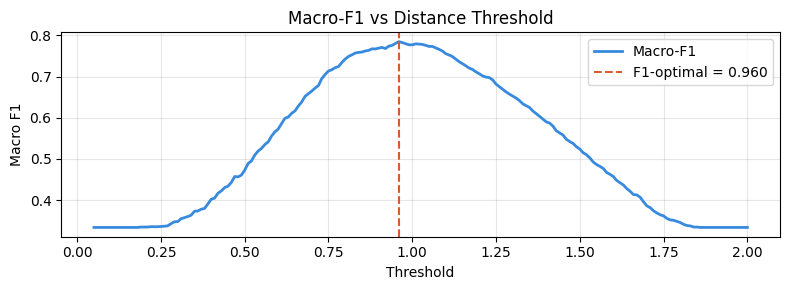

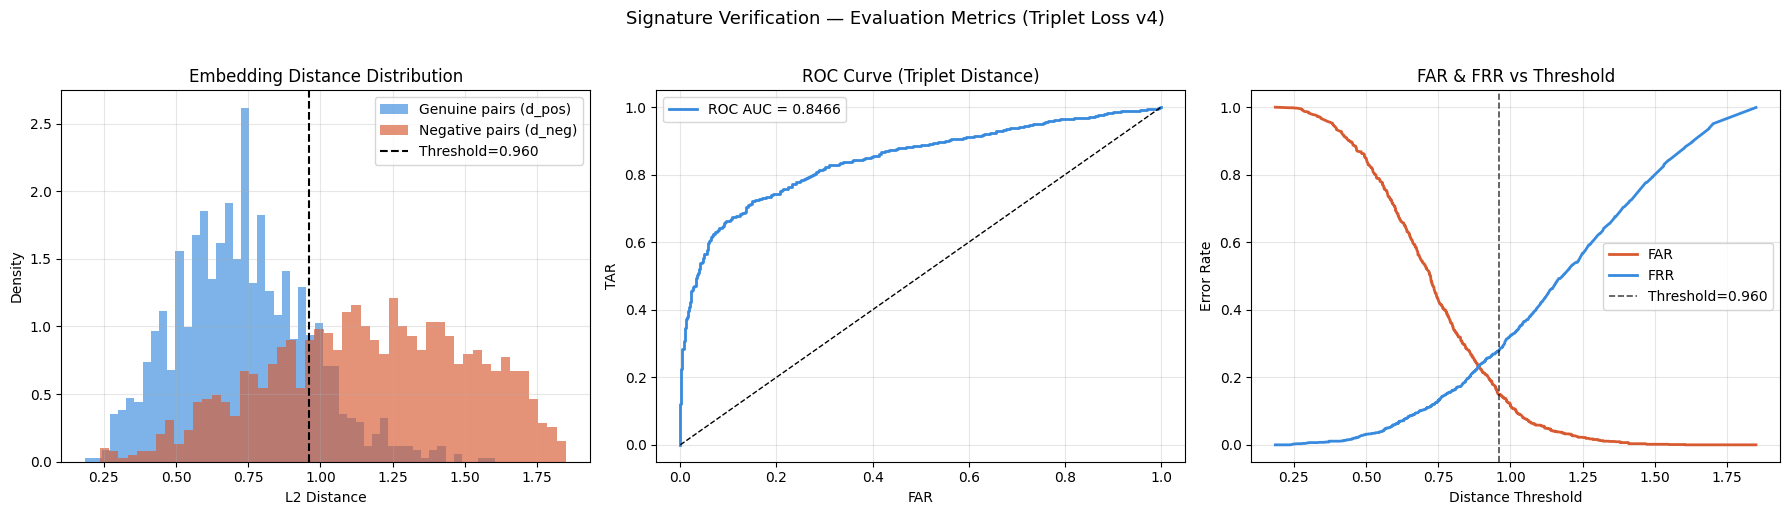


📊 KEY METRICS (threshold = 0.960)
   ROC-AUC  : 0.8466  ← area di bawah ROC curve (1.0 = perfect)
   EER      : nan%  ← makin kecil makin baik (< 5% sangat baik)


In [12]:
model.load_state_dict(torch.load('/content/best_signature_triplet_v4.pth', map_location=DEVICE))
model.eval()

_, _, all_d_pos, all_d_neg = eval_epoch(model, val_loader, criterion, DEVICE)

all_dists  = np.array(all_d_pos + all_d_neg)
all_labels = np.array([0] * len(all_d_pos) + [1] * len(all_d_neg))

# ── ROC curve & AUC ──────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(all_labels, all_dists)
auc_score = roc_auc_score(all_labels, all_dists)

# ── EER ───────────────────────────────────────────────────────────────────
fnr = 1.0 - tpr
try:
    eer     = brentq(lambda x: interp1d(fpr, fnr - fpr, fill_value='extrapolate')(x),
                     fpr[0], fpr[-1])
    eer_thr = float(interp1d(fpr, roc_thresholds)(eer))
except Exception:
    eer, eer_thr = float('nan'), float('nan')

# ── F1 threshold sweep ────────────────────────────────────────────────────
thresholds = np.arange(0.05, 2.01, 0.01)
f1_scores  = [f1_score(all_labels,
                        (all_dists > t).astype(int),
                        average='macro', zero_division=0)
               for t in thresholds]
f1_thr = float(thresholds[np.argmax(f1_scores)])
f1_best = max(f1_scores)

# ✅ v4: Ensemble threshold = rata-rata EER-optimal dan F1-optimal
if not np.isnan(eer_thr):
    THRESHOLD = float((eer_thr + f1_thr) / 2.0)
    print(f'🔍 EER-optimal threshold : {eer_thr:.3f}')
    print(f'🔍 F1-optimal  threshold : {f1_thr:.3f}  (F1={f1_best:.4f})')
    print(f'✅ Ensemble threshold    : {THRESHOLD:.3f}  (avg of both)')
else:
    THRESHOLD = f1_thr
    print(f'🔍 F1-optimal threshold (EER fallback): {THRESHOLD:.3f}  (F1={f1_best:.4f})')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(thresholds, f1_scores, color='#378ADD', lw=2, label='Macro-F1')
ax.axvline(f1_thr,   color='#D85A30', ls='--', lw=1.5, label=f'F1-optimal = {f1_thr:.3f}')
if not np.isnan(eer_thr):
    ax.axvline(eer_thr,  color='green', ls=':', lw=1.5, label=f'EER-optimal = {eer_thr:.3f}')
    ax.axvline(THRESHOLD, color='black', ls='-', lw=1.5, alpha=0.6, label=f'Ensemble = {THRESHOLD:.3f}')
ax.set_title('Macro-F1 vs Distance Threshold'); ax.set_xlabel('Threshold'); ax.set_ylabel('Macro F1')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ── Distance distribution plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_d_pos, bins=50, alpha=0.65, color='#378ADD', label='Genuine pairs (d_pos)', density=True)
axes[0].hist(all_d_neg, bins=50, alpha=0.65, color='#D85A30', label='Negative pairs (d_neg)', density=True)
axes[0].axvline(THRESHOLD, color='black', ls='--', lw=1.5, label=f'Threshold={THRESHOLD:.3f}')
axes[0].set_title('Embedding Distance Distribution'); axes[0].set_xlabel('L2 Distance')
axes[0].set_ylabel('Density'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr, tpr, color='#378ADD', lw=2, label=f'ROC AUC = {auc_score:.4f}')
if not np.isnan(eer):
    axes[1].scatter([eer], [1 - eer], color='#D85A30', s=80, zorder=5, label=f'EER = {eer:.2%}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve (Triplet Distance)'); axes[1].set_xlabel('FAR')
axes[1].set_ylabel('TAR'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(roc_thresholds, fpr[:len(roc_thresholds)], color='#D85A30', lw=2, label='FAR')
axes[2].plot(roc_thresholds, fnr[:len(roc_thresholds)], color='#378ADD', lw=2, label='FRR')
axes[2].axvline(THRESHOLD, color='black', ls='--', lw=1.2, alpha=0.7, label=f'Threshold={THRESHOLD:.3f}')
if not np.isnan(eer):
    axes[2].axhline(eer, color='gray', ls=':', lw=1.2, label=f'EER={eer:.2%}')
axes[2].set_title('FAR & FRR vs Threshold'); axes[2].set_xlabel('Distance Threshold')
axes[2].set_ylabel('Error Rate'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Signature Verification — Evaluation Metrics (Triplet Loss v4)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f'\n📊 KEY METRICS (threshold = {THRESHOLD:.3f})')
print(f'   ROC-AUC  : {auc_score:.4f}  ← area di bawah ROC curve (1.0 = perfect)')
print(f'   EER      : {eer:.2%}  ← makin kecil makin baik (< 5% sangat baik)')


📋 CLASSIFICATION REPORT
                    precision    recall  f1-score   support

         Genuine ✅       0.75      0.85      0.80      1200
Forgery/Impostor ❌       0.83      0.72      0.77      1200

          accuracy                           0.79      2400
         macro avg       0.79      0.79      0.78      2400
      weighted avg       0.79      0.79      0.78      2400



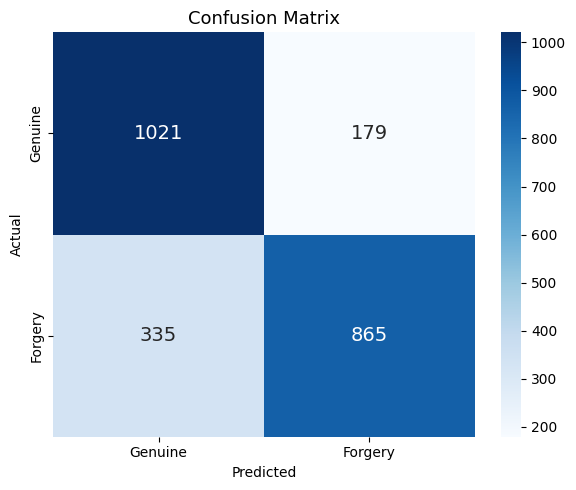


📊 SUMMARY (threshold = 0.960)
   Accuracy  : 78.58%
   ROC-AUC   : 0.8466
   EER       : nan%
   FAR       : 14.92%  ← forgeries/impostors accepted as genuine
   FRR       : 27.92%  ← genuine signatures rejected


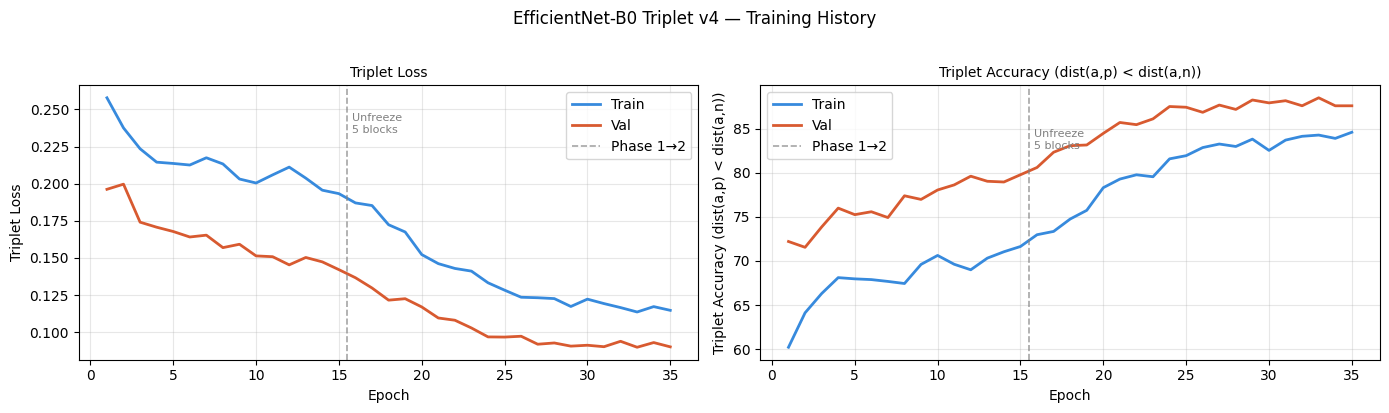

In [13]:
all_preds = (all_dists > THRESHOLD).astype(int)

print('=' * 55)
print('📋 CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(all_labels, all_preds, target_names=['Genuine ✅', 'Forgery/Impostor ❌']))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Forgery'],
            yticklabels=['Genuine', 'Forgery'], ax=ax, annot_kws={'size': 14})
ax.set_title('Confusion Matrix', fontsize=13)
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
FAR = fp / (fp + tn) if (fp + tn) > 0 else 0
FRR = fn / (fn + tp) if (fn + tp) > 0 else 0

print(f'\n📊 SUMMARY (threshold = {THRESHOLD:.3f})')
print(f'   Accuracy  : {accuracy_score(all_labels, all_preds):.2%}')
print(f'   ROC-AUC   : {auc_score:.4f}')
print(f'   EER       : {eer:.2%}')
print(f'   FAR       : {FAR:.2%}  ← forgeries/impostors accepted as genuine')
print(f'   FRR       : {FRR:.2%}  ← genuine signatures rejected')

# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep             = list(range(1, TOTAL_EPOCHS + 1))
phase_boundary = PHASE1_EPOCHS + 0.5

for ax, (k1, k2), ylabel in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
    ['Triplet Loss', 'Triplet Accuracy (dist(a,p) < dist(a,n))']
):
    y1 = history[k1]; y2 = history[k2]
    if 'acc' in k1:
        y1 = [v*100 for v in y1]; y2 = [v*100 for v in y2]
    ax.plot(ep, y1, label='Train', color='#378ADD', lw=2)
    ax.plot(ep, y2, label='Val',   color='#D85A30', lw=2)
    ax.axvline(phase_boundary, color='gray', ls='--', lw=1.2, alpha=0.7, label='Phase 1→2')
    ax.text(phase_boundary + 0.3,
            max(max(y1), max(y2)) * 0.96,
            'Unfreeze\n5 blocks', fontsize=8, color='gray', va='top')
    ax.set_title(ylabel, fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 Triplet v4 — Training History', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


## 11. 🔍 Per-Writer Verification (val set)

In [14]:
infer_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
def load_for_inference(path):
    img = autocrop_and_pad(Image.open(path), size=IMG_SIZE)
    return infer_transform(img)

print('📊 Per-Writer Verification Accuracy (val writers, first 10)')
print(f'   Reference = first genuine image per writer')
print(f'   Threshold = {THRESHOLD:.3f}\n')
per_writer_stats = {}
model.eval()

with torch.no_grad():
    for wid in val_writers[:10]:
        g_paths = genuine_index.get(wid, [])
        f_paths = forged_index.get(wid, [])
        if len(g_paths) < 2 or len(f_paths) < 1:
            continue

        ref_t = load_for_inference(g_paths[0]).unsqueeze(0).to(DEVICE)
        ref_e = model(ref_t)

        correct_g, total_g = 0, 0
        correct_f, total_f = 0, 0

        for p in g_paths[1:]:
            t = load_for_inference(p).unsqueeze(0).to(DEVICE)
            d = F.pairwise_distance(ref_e, model(t)).item()
            correct_g += (d < THRESHOLD); total_g += 1

        for p in f_paths:
            t = load_for_inference(p).unsqueeze(0).to(DEVICE)
            d = F.pairwise_distance(ref_e, model(t)).item()
            correct_f += (d >= THRESHOLD); total_f += 1

        total     = total_g + total_f
        correct   = correct_g + correct_f
        per_writer_stats[wid] = {
            'acc': correct / total if total > 0 else 0,
            'genuine_acc': correct_g / total_g if total_g > 0 else 0,
            'forgery_acc': correct_f / total_f if total_f > 0 else 0,
        }
        print(f'   Writer {wid:>4}: overall={per_writer_stats[wid]["acc"]:.1%} '
              f'| genuine={per_writer_stats[wid]["genuine_acc"]:.1%} '
              f'| forgery={per_writer_stats[wid]["forgery_acc"]:.1%} '
              f'({correct}/{total})')

if per_writer_stats:
    mean_acc  = np.mean([v['acc']         for v in per_writer_stats.values()])
    mean_facc = np.mean([v['forgery_acc'] for v in per_writer_stats.values()])
    print(f'\n   Mean overall acc  : {mean_acc:.2%}')
    print(f'   Mean forgery det. : {mean_facc:.2%}  ← kemampuan deteksi skilled forgery')


📊 Per-Writer Verification Accuracy (val writers, first 10)
   Reference = first genuine image per writer
   Threshold = 0.960

   Writer   46: overall=90.5% | genuine=100.0% | forgery=85.7% (19/21)
   Writer  136: overall=85.7% | genuine=71.4% | forgery=92.9% (18/21)
   Writer   16: overall=90.5% | genuine=71.4% | forgery=100.0% (19/21)
   Writer   45: overall=90.5% | genuine=85.7% | forgery=92.9% (19/21)
   Writer  142: overall=57.1% | genuine=100.0% | forgery=35.7% (12/21)
   Writer   43: overall=90.5% | genuine=100.0% | forgery=85.7% (19/21)
   Writer   60: overall=57.1% | genuine=28.6% | forgery=71.4% (12/21)
   Writer   76: overall=61.9% | genuine=85.7% | forgery=50.0% (13/21)
   Writer  118: overall=81.0% | genuine=71.4% | forgery=85.7% (17/21)
   Writer  150: overall=33.3% | genuine=100.0% | forgery=0.0% (7/21)

   Mean overall acc  : 73.81%
   Mean forgery det. : 70.00%  ← kemampuan deteksi skilled forgery


## 12. 💾 Save & Export ke Google Drive

In [15]:
total_params    = sum(p.numel() for p in model.parameters())
trainable_final = sum(p.numel() for p in model.parameters() if p.requires_grad)

LOCAL_MODEL_PATH = '/content/EfficientNet-B0-triplet-v4.pth'
LOCAL_META_PATH  = '/content/efficientnet_triplet_v4_metadata.json'

torch.save({
    'model_state_dict' : model.state_dict(),
    'best_val_acc'     : best_val_acc,
    'threshold'        : THRESHOLD,
    'embedding_dim'    : 512,
    'img_size'         : IMG_SIZE,
    'imagenet_mean'    : IMAGENET_MEAN,
    'imagenet_std'     : IMAGENET_STD,
    'val_writers'      : val_writers,
    'eer'              : float(eer) if not np.isnan(eer) else None,
    'auc_roc'          : float(auc_score),
    'saved_at'         : datetime.now().isoformat()
}, LOCAL_MODEL_PATH)

metadata = {
    'project'          : 'Signature Forgery Detector — EfficientNet-B0 Triplet v4',
    'backbone'         : 'EfficientNet-B0 (ImageNet pretrained)',
    'loss'             : 'TripletMarginLoss (margin=0.3)',
    'embedding_dim'    : 512,
    'dataset'          : 'archive.zip (Fake Handwriting folder)',
    'total_writers'    : len(writers),
    'train_writers'    : len(train_writers),
    'val_writers_count': len(val_writers),
    'triplet_strategy' : '50% skilled-forgery / 50% impostor, resampled every epoch',
    'augmentation'     : 'SignatureAugmentation + RandomPerspective + stronger RandomErasing',
    'data_pipeline'    : 'autocrop-to-ink + square-pad + LMDB cache 224x224 + AMP',
    'threshold_method' : f'Ensemble: EER-optimal + macro-F1 | value={THRESHOLD:.3f}',
    'training_phases'  : [
        {'phase': 1, 'epochs': PHASE1_EPOCHS, 'lr': '1e-3',
         'scheduler': 'CosineAnnealingWarmRestarts(T_0=5)', 'backbone': 'frozen'},
        {'phase': 2, 'epochs': PHASE2_EPOCHS,
         'lr': 'backbone=1e-5 / head=5e-5',
         'scheduler': f'LinearWarmup({WARMUP_EPOCHS}ep) + CosineAnnealing',
         'backbone': 'last 5 blocks unfrozen'}
    ],
    'gradient_clipping'        : f'max_norm={GRAD_CLIP_NORM}',
    'best_val_triplet_acc'     : round(best_val_acc, 4),
    'roc_auc'                  : round(float(auc_score), 4),
    'eer'                      : round(float(eer), 4) if not np.isnan(eer) else None,
    'threshold'                : THRESHOLD,
    'total_params'             : total_params,
    'training_history'         : history
}
with open(LOCAL_META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

# ✅ PATH DISESUAIKAN: simpan output ke Fake Handwriting/outputs/
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/Fake Handwriting/outputs'
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
shutil.copy(LOCAL_MODEL_PATH, DRIVE_OUTPUT_DIR)
shutil.copy(LOCAL_META_PATH,  DRIVE_OUTPUT_DIR)

print('✅ Model   :', os.path.join(DRIVE_OUTPUT_DIR, os.path.basename(LOCAL_MODEL_PATH)))
print('✅ Metadata:', os.path.join(DRIVE_OUTPUT_DIR, os.path.basename(LOCAL_META_PATH)))
print()
print('📊 Final Summary')
print(f'   Total writers         : {len(writers)}')
print(f'   Train / Val writers   : {len(train_writers)} / {len(val_writers)}')
print(f'   Best Val Triplet Acc  : {best_val_acc:.2%}')
print(f'   ROC-AUC               : {auc_score:.4f}')
print(f'   EER                   : {eer:.2%}')
print(f'   Optimal Threshold     : {THRESHOLD:.3f}  (EER+F1 ensemble)')
print(f'   Embedding dim         : 512')
print(f'   Loss                  : TripletMarginLoss (margin=0.3)')
print(f'   Fine-tune blocks      : 5 (backbone=1e-5 / head=5e-5)')
print(f'   Gradient clipping     : max_norm={GRAD_CLIP_NORM}')


✅ Model   : /content/drive/MyDrive/Fake Handwriting/outputs/EfficientNet-B0-triplet-v4.pth
✅ Metadata: /content/drive/MyDrive/Fake Handwriting/outputs/efficientnet_triplet_v4_metadata.json

📊 Final Summary
   Total writers         : 150
   Train / Val writers   : 120 / 30
   Best Val Triplet Acc  : 88.49%
   ROC-AUC               : 0.8466
   EER                   : nan%
   Optimal Threshold     : 0.960  (EER+F1 ensemble)
   Embedding dim         : 512
   Loss                  : TripletMarginLoss (margin=0.3)
   Fine-tune blocks      : 5 (backbone=1e-5 / head=5e-5)
   Gradient clipping     : max_norm=1.0


## 🔍 Bonus: Cek GPU Utilization

In [16]:
!nvidia-smi --query-gpu=utilization.gpu,utilization.memory,memory.used,memory.total --format=csv

utilization.gpu [%], utilization.memory [%], memory.used [MiB], memory.total [MiB]
16 %, 2 %, 1707 MiB, 15360 MiB
